# Science Image Reduction

This notebook applies the final calibration products to the raw 158P science exposure.

The final master flat is normalized independently for the two CCD amplifiers. This choice was adopted after an exploratory global normalization introduced an artificial discontinuity at the amplifier boundary.

Workflow:

1. Load the raw science exposure.
2. Apply two-amplifier overscan correction and trim the image.
3. Subtract the master bias.
4. Build a bad-pixel mask from extreme bias and flat values.
5. Divide by the amplifier-normalized R-band master flat.
6. Quantify the large-scale background uniformity.
7. Save the calibrated FITS image for inspection in DS9.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import SigmaClip, sigma_clipped_stats, mad_std
from photutils.background import Background2D, MedianBackground

In [2]:
PROJECT_DIR = Path("..").resolve()

PRODUCTS_DIR = PROJECT_DIR / "products"
FIGURES_DIR = PROJECT_DIR / "Figures"

PRODUCTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

science_candidates = sorted(PROJECT_DIR.glob("*.fits*"))
science_file = science_candidates[0]

print("Science file:", science_file.name)

Science file: c09i_180419_050252_ori.fits.fz


In [3]:
def get_image_hdu(filename):
    """Return the first HDU containing a 2D image."""
    with fits.open(filename) as hdul:
        for i, hdu in enumerate(hdul):
            if hdu.data is not None and hdu.data.ndim == 2:
                return i
    raise ValueError(f"No 2D image found in {filename}")


def overscan_correct_and_trim(data):
    """Correct the two amplifiers row-by-row and return a 2048x2048 image."""

    amp1 = data[:, 10:1034].astype(float)
    overscan1 = data[:, 1044:1084].astype(float)
    amp1 -= np.median(overscan1, axis=1, keepdims=True)

    amp2 = data[:, 1134:2158].astype(float)
    overscan2 = data[:, 1084:1124].astype(float)
    amp2 -= np.median(overscan2, axis=1, keepdims=True)

    return np.hstack([amp1, amp2])


def binned_background_profile(image, bin_width=64):
    """Return a robust 1D background profile binned along X."""
    x, profile = [], []
    nx = image.shape[1]

    for x0 in range(0, nx, bin_width):
        x1 = min(x0 + bin_width, nx)
        x.append((x0 + x1) / 2)
        profile.append(np.nanmedian(image[:, x0:x1]))

    return np.asarray(x), np.asarray(profile)

## Load science image and calibration products

In [4]:
science_hdu = get_image_hdu(science_file)

with fits.open(science_file) as hdul:
    raw_science = hdul[science_hdu].data.astype(float)
    science_header = hdul[science_hdu].header.copy()

with fits.open(PRODUCTS_DIR / "master_bias.fits") as hdul:
    master_bias = hdul[0].data.astype(float)

with fits.open(PRODUCTS_DIR / "master_flat_r_ampnorm.fits") as hdul:
    master_flat = hdul[0].data.astype(float)

print("OBJECT:", science_header.get("OBJECT"))
print("FILTER2:", science_header.get("FILTER2"))
print("EXPTIME:", science_header.get("EXPTIME"))
print("DETECTOR:", science_header.get("DETECTOR"))
print("Raw science shape:", raw_science.shape)
print("Master Bias shape:", master_bias.shape)
print("Master Flat shape:", master_flat.shape)

OBJECT: 158P
FILTER2: r
EXPTIME: 60.0
DETECTOR: Tek2K_3
Raw science shape: (2048, 2168)
Master Bias shape: (2048, 2048)
Master Flat shape: (2048, 2048)


## Calibrate the science exposure

In [5]:
science_trimmed = overscan_correct_and_trim(raw_science)
science_bias_corrected = science_trimmed - master_bias

bad_flat = (
    ~np.isfinite(master_flat) |
    (master_flat < 0.5) |
    (master_flat > 1.5)
)

bad_bias = (
    ~np.isfinite(master_bias) |
    (master_bias < -500) |
    (master_bias > 500)
)

bad_pixel_mask = bad_flat | bad_bias

safe_flat = master_flat.copy()
safe_flat[bad_pixel_mask] = np.nan

science_calibrated = science_bias_corrected / safe_flat

print("Trimmed science shape:", science_trimmed.shape)
print(
    f"Bad pixels: {np.sum(bad_pixel_mask)} "
    f"({100*np.sum(bad_pixel_mask)/bad_pixel_mask.size:.4f} %)"
)

Trimmed science shape: (2048, 2048)
Bad pixels: 14372 (0.3427 %)


In [6]:
mean_before, median_before, std_before = sigma_clipped_stats(
    science_bias_corrected, sigma=3, maxiters=5
)
mean_after, median_after, std_after = sigma_clipped_stats(
    science_calibrated, sigma=3, maxiters=5
)

print("=== Science image statistics ===")
print(
    f"Before flat: mean={mean_before:.3f}, "
    f"median={median_before:.3f}, std={std_before:.3f} ADU"
)
print(
    f"After flat : mean={mean_after:.3f}, "
    f"median={median_after:.3f}, std={std_after:.3f} ADU"
)

=== Science image statistics ===
Before flat: mean=32.020, median=32.000, std=6.764 ADU
After flat : mean=32.114, median=32.096, std=6.732 ADU


## Validate large-scale background uniformity

The flat-field correction should improve the large-scale uniformity without introducing a discontinuity at the boundary between the two amplifiers.

In [7]:
sigma_clip = SigmaClip(sigma=3.0, maxiters=10)
bkg_estimator = MedianBackground()

background_before = Background2D(
    science_bias_corrected,
    box_size=(64, 64),
    filter_size=(3, 3),
    sigma_clip=sigma_clip,
    bkg_estimator=bkg_estimator,
    mask=bad_pixel_mask
)

background_after = Background2D(
    science_calibrated,
    box_size=(64, 64),
    filter_size=(3, 3),
    sigma_clip=sigma_clip,
    bkg_estimator=bkg_estimator,
    mask=bad_pixel_mask
)

bkg_before_map = background_before.background
bkg_after_map = background_after.background

_, med_bkg_before, std_bkg_before = sigma_clipped_stats(
    bkg_before_map, sigma=3
)
_, med_bkg_after, std_bkg_after = sigma_clipped_stats(
    bkg_after_map, sigma=3
)

mad_before = mad_std(bkg_before_map, ignore_nan=True)
mad_after = mad_std(bkg_after_map, ignore_nan=True)

left_before = np.nanmedian(bkg_before_map[:, :1024])
right_before = np.nanmedian(bkg_before_map[:, 1024:])
left_after = np.nanmedian(bkg_after_map[:, :1024])
right_after = np.nanmedian(bkg_after_map[:, 1024:])

print("=== Background uniformity ===")
print(
    f"Before: median={med_bkg_before:.4f}, "
    f"std={std_bkg_before:.4f}, MAD std={mad_before:.4f} ADU"
)
print(
    f"After : median={med_bkg_after:.4f}, "
    f"std={std_bkg_after:.4f}, MAD std={mad_after:.4f} ADU"
)

print("\nAmplifier background difference")
print(f"Before: {left_before-right_before:.4f} ADU")
print(f"After : {left_after-right_after:.4f} ADU")

=== Background uniformity ===
Before: median=32.0484, std=0.5469, MAD std=0.6315 ADU
After : median=32.1062, std=0.2927, MAD std=0.3119 ADU

Amplifier background difference
Before: -0.2313 ADU
After : -0.2277 ADU


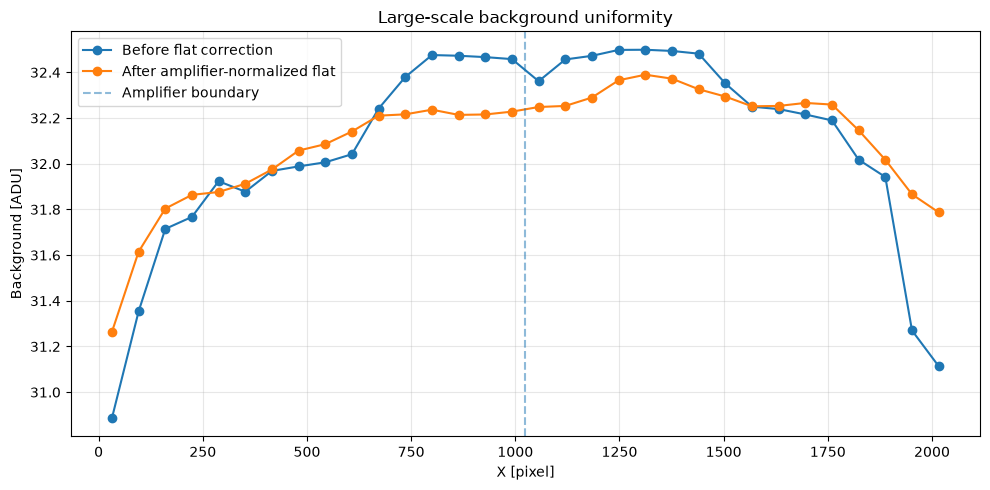

In [8]:
x_before, profile_before = binned_background_profile(bkg_before_map, bin_width=64)
x_after, profile_after = binned_background_profile(bkg_after_map, bin_width=64)

plt.figure(figsize=(10, 5))
plt.plot(x_before, profile_before, marker="o", label="Before flat correction")
plt.plot(
    x_after,
    profile_after,
    marker="o",
    label="After amplifier-normalized flat"
)
plt.axvline(1024, linestyle="--", alpha=0.5, label="Amplifier boundary")

plt.xlabel("X [pixel]")
plt.ylabel("Background [ADU]")
plt.title("Large-scale background uniformity")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "background_uniformity.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

For this dataset, the amplifier-normalized flat preserves the original background balance across the readout boundary while substantially reducing the large-scale background dispersion.

## Final calibrated image

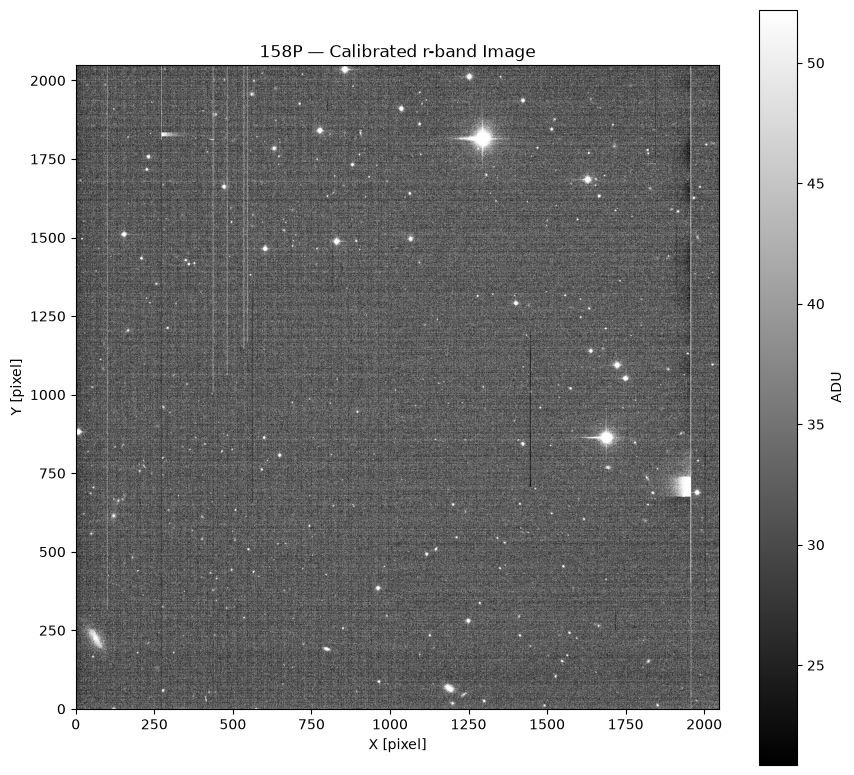

In [9]:
vmin, vmax = np.nanpercentile(science_calibrated, [5, 99.5])

plt.figure(figsize=(9, 8))
plt.imshow(
    science_calibrated,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(label="ADU")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("158P — Calibrated r-band Image")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "158P_calibrated_r.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

## Save calibrated FITS image

The calibrated FITS file is saved locally for inspection in SAOImage DS9. Raw and processed FITS files are excluded from the GitHub repository via `.gitignore`.

In [10]:
output_header = science_header.copy()

output_header["IMAGETYP"] = "CALIBRATED"
output_header["HISTORY"] = "Two-amplifier overscan correction applied"
output_header["HISTORY"] = "Image trimmed to 2048x2048 detector region"
output_header["HISTORY"] = "Master bias subtracted"
output_header["HISTORY"] = "R-band master flat applied"
output_header["HISTORY"] = "Flat normalized independently by CCD amplifier"
output_header["HISTORY"] = "Bad detector pixels stored as NaN"

final_path = PRODUCTS_DIR / "158P_calibrated_r.fits"

fits.writeto(
    final_path,
    science_calibrated.astype(np.float32),
    header=output_header,
    overwrite=True
)

print("Saved:", final_path)

Saved: C:\Users\rodri\NoirLab\products\158P_calibrated_r.fits
